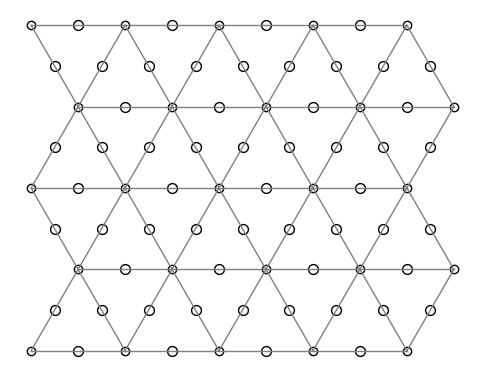

In [6]:
import matplotlib.pyplot as plt
import numpy as np

Lx, Ly = 5, 5
a = 1.0
points = {}
lines = []
midpoints = []

# 格子点生成
for i in range(Lx):
    for j in range(Ly):
        x = i + 0.5 * (j % 2)
        y = j * np.sqrt(3)/2
        points[(i, j)] = (x, y)

# リンクと中点
for (i, j), (x, y) in points.items():
    neighbors = []
    if (i+1, j) in points:
        neighbors.append((i+1, j))
    if j % 2 == 0:
        if (i, j+1) in points:
            neighbors.append((i, j+1))
        if (i-1, j+1) in points:
            neighbors.append((i-1, j+1))
    else:
        if (i, j+1) in points:
            neighbors.append((i, j+1))
        if (i+1, j+1) in points:
            neighbors.append((i+1, j+1))

    for ni, nj in neighbors:
        if (ni, nj) in points:
            x1, y1 = points[(ni, nj)]
            lines.append(((x, y), (x1, y1)))
            mx = (x + x1) / 2
            my = (y + y1) / 2
            midpoints.append((mx, my))

# 描画
fig, ax = plt.subplots(figsize=(6, 6))
for (x0, y0), (x1, y1) in lines:
    ax.plot([x0, x1], [y0, y1], color='gray', lw=1)

ax.scatter(*zip(*points.values()),  facecolors='white', edgecolors='black', )
ax.scatter(*zip(*midpoints), facecolors='white', edgecolors='black', s=50, label='Midpoints')

ax.set_aspect('equal')
ax.axis('off')
#plt.title("Triangular Lattice with Midpoints")

# PNGファイルとして保存
plt.savefig("triangular_lattice.png", dpi=300, bbox_inches='tight')

# （必要なら表示もする）
# plt.show()
